In [13]:
!pip install kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory


In [14]:
import kagglehub

path = kagglehub.competition_download('classification-of-oil-and-gas')

print("Path: ", path)

Path:  /root/.cache/kagglehub/competitions/classification-of-oil-and-gas


In [15]:
# поменять путь
!mv /root/.cache/kagglehub/competitions/classification-of-oil-and-gas classification-of-oil-and-gas

In [16]:
!pip install xgboost lightgbm catboost shap optuna -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

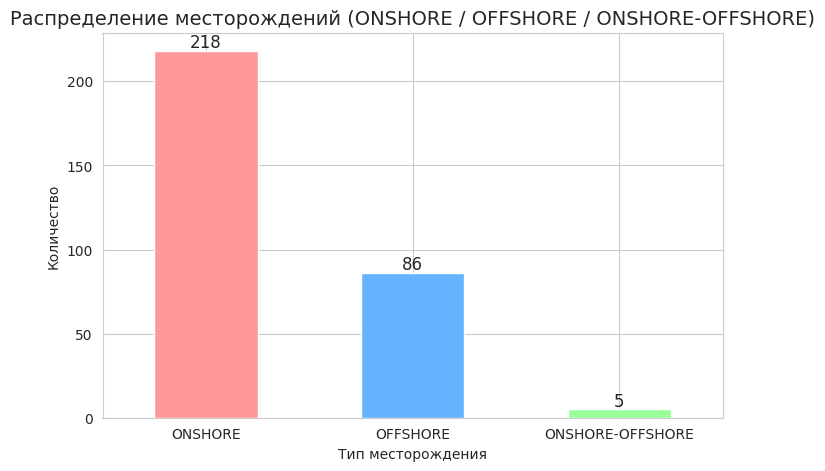

пропуски:
Region        38
Basin name    38
Longitude     30
Country       27
Latitude      27
dtype: int64
Распределение классов: {np.int64(0): np.int64(86), np.int64(1): np.int64(218), np.int64(2): np.int64(5)}
                   CV_mean_f1  CV_std_f1    Val_f1
XGBoost              0.612541   0.130597  0.578526
LightGBM             0.605444   0.120175  0.554527
Random Forest        0.605283   0.080866  0.550366
CatBoost             0.625622   0.137437  0.550366
Gradient Boosting    0.597695   0.126233  0.542135
0:	learn: 1.0590066	total: 9.84ms	remaining: 2.94s
50:	learn: 0.3601064	total: 337ms	remaining: 1.65s
100:	learn: 0.2138549	total: 662ms	remaining: 1.3s
150:	learn: 0.1456145	total: 1.01s	remaining: 996ms
200:	learn: 0.1076613	total: 1.34s	remaining: 659ms
250:	learn: 0.0840195	total: 1.66s	remaining: 325ms
299:	learn: 0.0679784	total: 2s	remaining: 0us


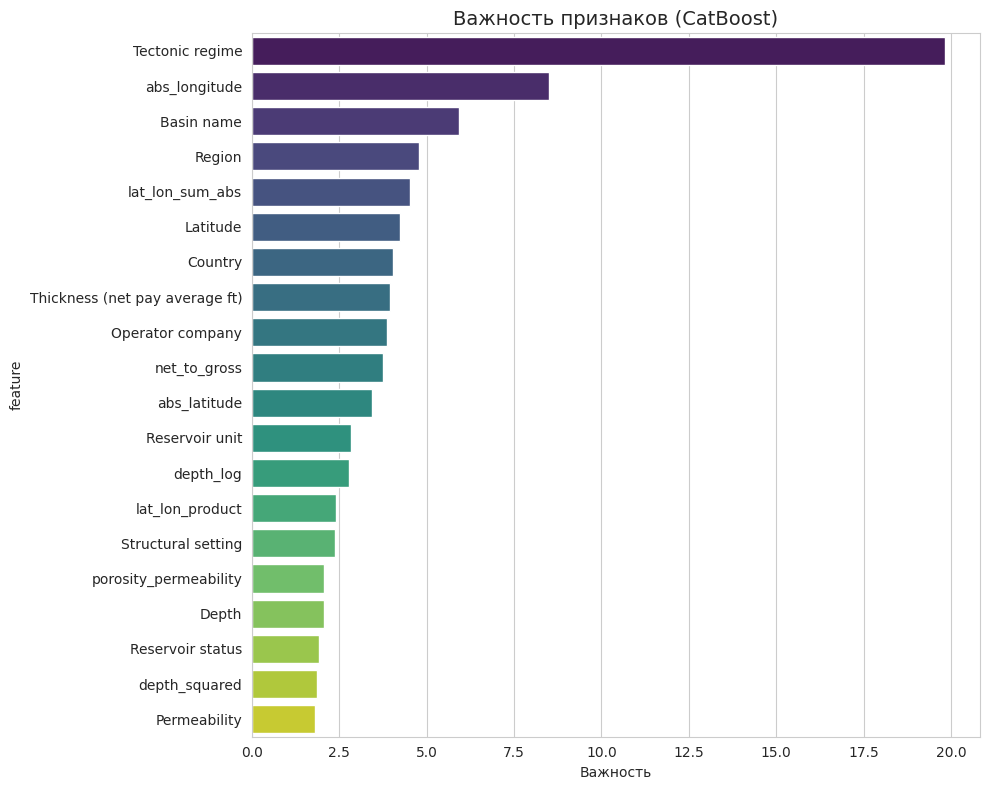

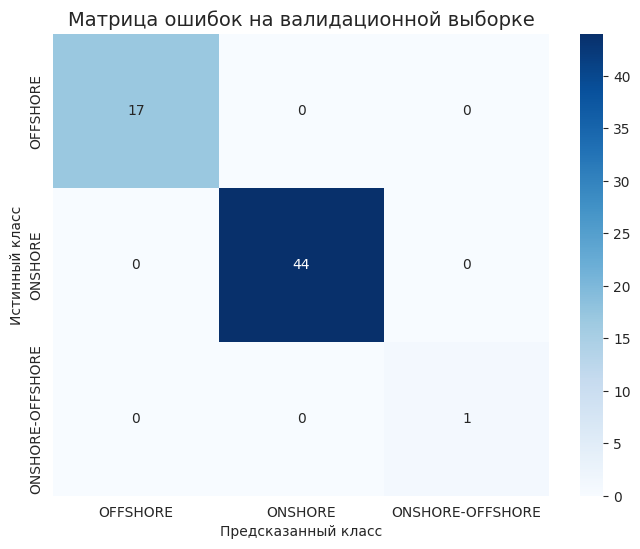

In [ ]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

train = pd.read_csv('classification-of-oil-and-gas/train_oil.csv')
test = pd.read_csv('classification-of-oil-and-gas/oil_test.csv')

target_col = 'Onshore/Offshore'

plt.figure(figsize=(8, 5))
colors = ['#ff9999', '#66b3ff', '#99ff99']
train[target_col].value_counts().plot(kind='bar', color=colors)
plt.title('Распределение месторождений (ONSHORE / OFFSHORE / ONSHORE-OFFSHORE)', fontsize=14)
plt.xlabel('Тип месторождения')
plt.ylabel('Количество')
plt.xticks(rotation=0)
for i, v in enumerate(train[target_col].value_counts().values):
    plt.text(i, v + 2, str(v), ha='center', fontsize=12)
plt.show()

print("пропуски:")
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing)
else:
    print("нет")


def preprocess_data(df, is_train=True, target_col=None, fit_scaler=True, scaler=None, encoder=None):
    """предобработка данных"""
    data = df.copy()

    if 'Field name' in data.columns:
        data.drop('Field name', axis=1, inplace=True)

    if is_train and target_col:
        y = data[target_col]
        X = data.drop(target_col, axis=1)
    else:
        X = data
        y = None

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

    for col in numeric_cols:
        if X[col].isnull().sum() > 0:
            X[col].fillna(X[col].median(), inplace=True)

    for col in categorical_cols:
        if X[col].isnull().sum() > 0:
            X[col].fillna('Unknown', inplace=True)

    if 'Latitude' in X.columns:
        X['abs_latitude'] = X['Latitude'].abs()
        X['is_northern'] = (X['Latitude'] > 0).astype(int)
        X['latitude_zone'] = pd.cut(X['Latitude'].abs(), bins=[0, 30, 60, 90], labels=['low', 'mid', 'high'])
        categorical_cols.append('latitude_zone')

    if 'Longitude' in X.columns:
        X['abs_longitude'] = X['Longitude'].abs()
        X['is_eastern'] = (X['Longitude'] > 0).astype(int)

    if 'Latitude' in X.columns and 'Longitude' in X.columns:
        X['lat_lon_product'] = X['Latitude'] * X['Longitude']
        X['lat_lon_sum_abs'] = X['Latitude'].abs() + X['Longitude'].abs()

    depth_col = 'Depth'
    gross_thick_col = 'Thickness (gross average ft)'
    net_thick_col = 'Thickness (net pay average ft)'

    if depth_col in X.columns:
        X['depth_log'] = np.log1p(X[depth_col])
        X['depth_squared'] = X[depth_col] ** 2

    if gross_thick_col in X.columns and net_thick_col in X.columns:
        X['net_to_gross'] = X[net_thick_col] / (X[gross_thick_col] + 1)
        X['thickness_diff'] = X[gross_thick_col] - X[net_thick_col]

    if depth_col in X.columns and gross_thick_col in X.columns:
        X['depth_to_thickness'] = X[depth_col] / (X[gross_thick_col] + 1)

    if 'Porosity' in X.columns and 'Permeability' in X.columns:
        X['porosity_permeability'] = X['Porosity'] * np.log1p(X['Permeability'])
        X['porosity_squared'] = X['Porosity'] ** 2

    if fit_scaler and is_train:
        from sklearn.preprocessing import OrdinalEncoder
        categorical_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X[categorical_cols] = categorical_encoder.fit_transform(X[categorical_cols])
    else:
        if encoder:
            categorical_encoder = encoder
            X[categorical_cols] = categorical_encoder.transform(X[categorical_cols])
        else:
            for col in categorical_cols:
                from sklearn.preprocessing import LabelEncoder
                le = LabelEncoder()
                X[col] = le.fit_transform(X[col].astype(str))

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    if fit_scaler and is_train:
        scaler = StandardScaler()
        X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
    else:
        if scaler:
            X[numeric_cols] = scaler.transform(X[numeric_cols])
        else:
            for col in numeric_cols:
                X[col] = (X[col] - X[col].mean()) / (X[col].std() + 1e-8)

    if is_train:
        return X, y, scaler, categorical_encoder if 'categorical_encoder' in dir() else None
    else:
        return X, y

X_train_full, y_train_full, scaler, categorical_encoder = preprocess_data(
    train, is_train=True, target_col=target_col, fit_scaler=True
)
X_test, _ = preprocess_data(
    test, is_train=False, fit_scaler=False, scaler=scaler, encoder=categorical_encoder
)

le_target = LabelEncoder()
y_train_full_encoded = le_target.fit_transform(y_train_full)

print(f"Распределение классов: {dict(zip(*np.unique(y_train_full_encoded, return_counts=True)))}")

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full_encoded,
    test_size=0.2, random_state=42, stratify=y_train_full_encoded
)
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, random_state=42, verbose=0),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    val_f1 = f1_score(y_val, y_pred, average='macro')
    results[name] = {
        'CV_mean_f1': scores.mean(),
        'CV_std_f1': scores.std(),
        'Val_f1': val_f1
    }

results_df = pd.DataFrame(results).T.sort_values('Val_f1', ascending=False)
print(results_df)

best_catboost = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    border_count=128,
    random_seed=42,
    verbose=50
)

best_catboost.fit(X_train, y_train)
y_pred_val = best_catboost.predict(X_val)
val_f1 = f1_score(y_val, y_pred_val, average='macro')



ensemble = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=150, random_state=42, use_label_encoder=False, eval_metric='mlogloss')),
        ('cat', CatBoostClassifier(iterations=200, random_state=42, verbose=0))
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_val)
ensemble_f1 = f1_score(y_val, y_pred_ensemble, average='macro')


if ensemble_f1 > val_f1:
    final_model = ensemble
    final_f1 = ensemble_f1
else:
    final_model = best_catboost
    final_f1 = val_f1

if final_model == ensemble:
    final_model.fit(X_train_full, y_train_full_encoded)
else:
    final_model = CatBoostClassifier(
        iterations=400, depth=6, learning_rate=0.05, l2_leaf_reg=3,
        border_count=128, random_seed=42, verbose=0
    )
    final_model.fit(X_train_full, y_train_full_encoded)




if final_model != ensemble:
    feature_importance = pd.DataFrame({
        'feature': X_train_full.columns,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)


    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance.head(20), x='importance', y='feature', palette='viridis')
    plt.title('Важность признаков (CatBoost)', fontsize=14)
    plt.xlabel('Важность')
    plt.tight_layout()
    plt.show()


y_pred_val_final = final_model.predict(X_val)
cm = confusion_matrix(y_val, y_pred_val_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Матрица ошибок на валидационной выборке', fontsize=14)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()


In [18]:
test_pred_encoded = final_model.predict(X_test)

if hasattr(test_pred_encoded, 'flatten'):
    test_pred_encoded = test_pred_encoded.flatten()
elif isinstance(test_pred_encoded, np.ndarray) and test_pred_encoded.ndim > 1:
    test_pred_encoded = test_pred_encoded.reshape(-1)

if isinstance(test_pred_encoded[0], str) or isinstance(test_pred_encoded[0], np.str_):
    mapping = {
        'OFFSHORE': 0,
        'ONSHORE': 1,
        'ONSHORE-OFFSHORE': 2
    }
    test_pred_numeric = np.array([mapping.get(x, 0) for x in test_pred_encoded])
else:
    test_pred_numeric = test_pred_encoded.astype(int)

submission = pd.DataFrame({
    'index': np.arange(len(test_pred_numeric)),
    'Onshore/Offshore': test_pred_numeric
})



submission.to_csv('submission.csv', index=True)

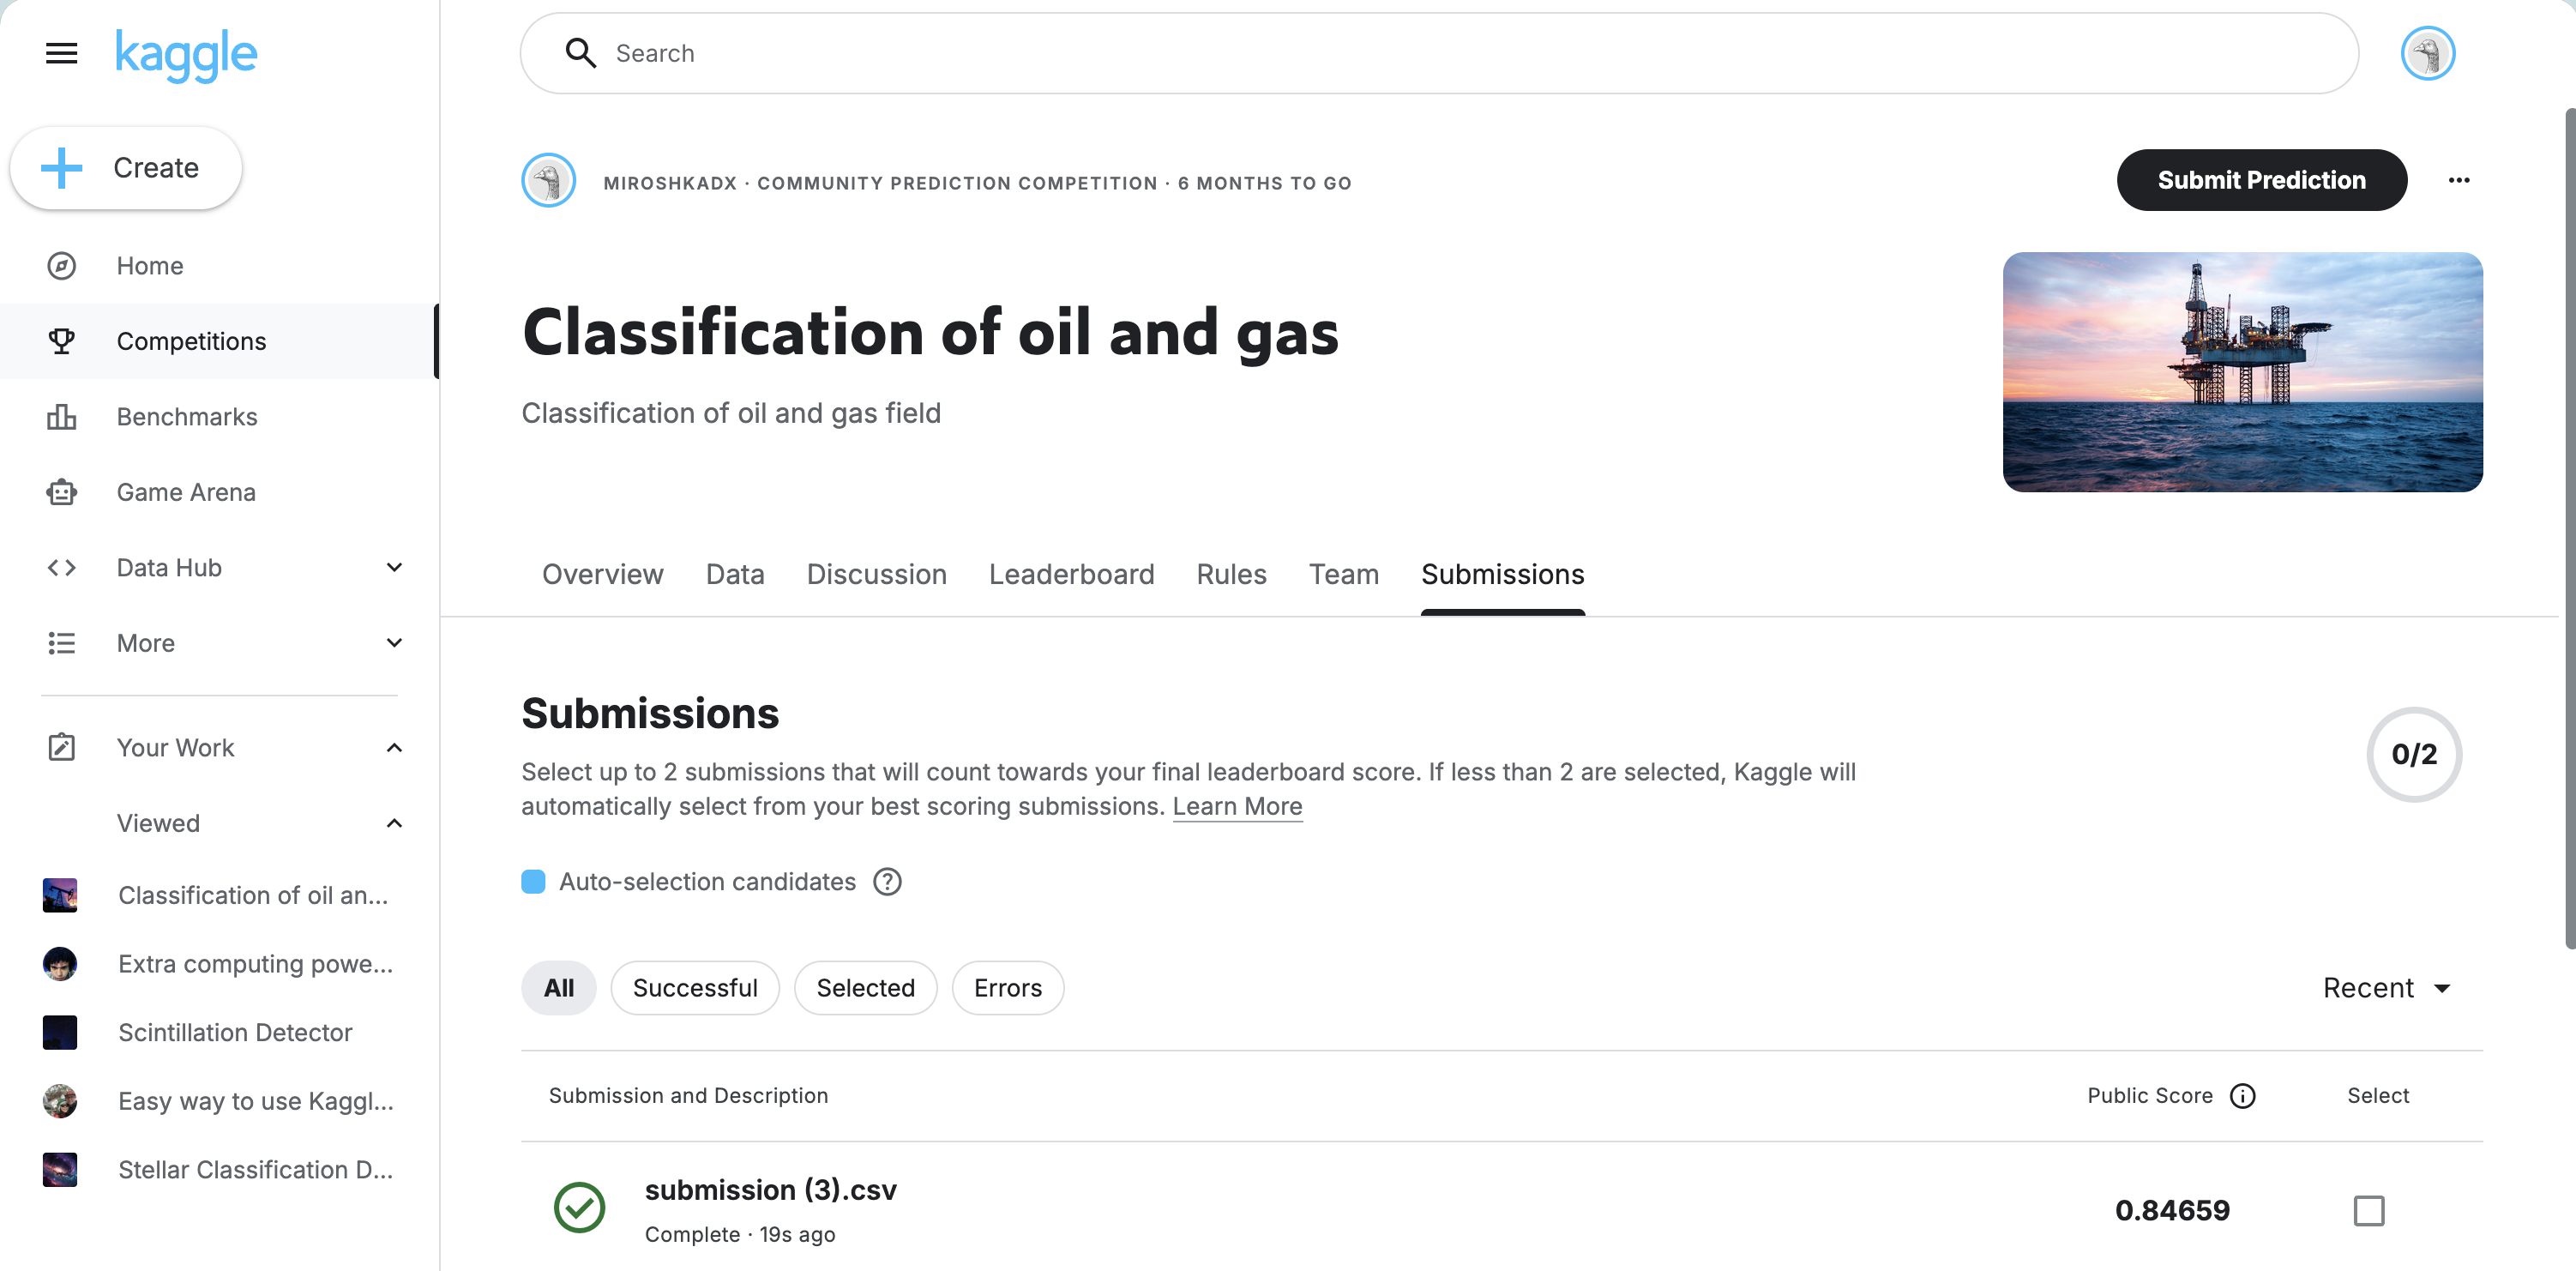